In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [2]:
# Load Wine Dataset
wine = load_wine()

X = wine.data
y = wine.target

df = pd.DataFrame(X, columns=wine.feature_names)

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (178, 13)
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  prol

C:\Users\Lenovo\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Lenovo\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Lenovo\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Lenovo\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

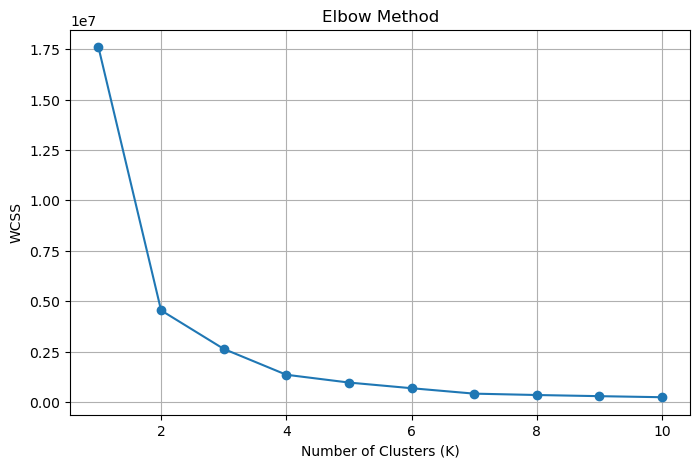

In [14]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42,
        n_init='auto'
    )

    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

In [15]:
optimal_k = 3

kmeans = KMeans(
    n_clusters=optimal_k,
    init='k-means++',
    random_state=42,
    n_init='auto'
)

clusters = kmeans.fit_predict(X)

df["Cluster"] = clusters

print(df.head())

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  Cluster  
0         

C:\Users\Lenovo\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


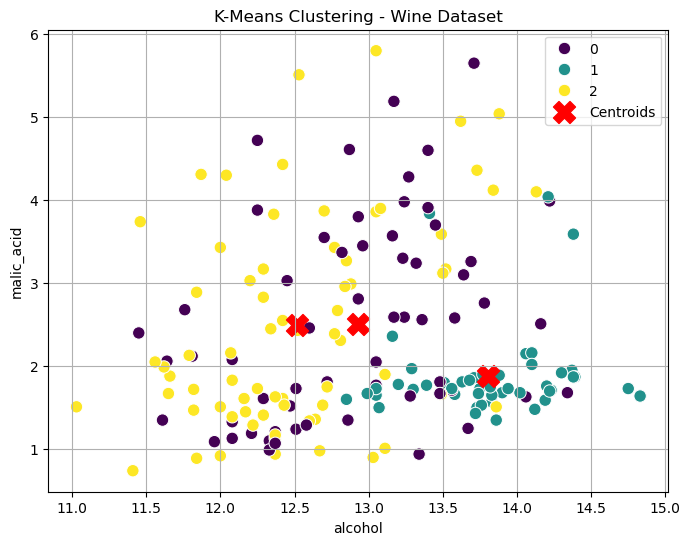

In [5]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df.iloc[:,0],
    y=df.iloc[:,1],
    hue=df["Cluster"],
    palette="viridis",
    s=80
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    color="red",
    marker="X",
    s=250,
    label="Centroids"
)

plt.title("K-Means Clustering - Wine Dataset")
plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])
plt.legend()
plt.grid(True)
plt.show()

In [6]:
silhouette_avg = silhouette_score(X, clusters)

print("Silhouette Score:", round(silhouette_avg,3))

Silhouette Score: 0.571


In [7]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [8]:
pca = PCA(n_components=2)

principal_components = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(
    principal_components,
    columns=["Principal_Component_1",
             "Principal_Component_2"]
)

df_pca["True_Cluster"] = y

print(df_pca.head())

   Principal_Component_1  Principal_Component_2  True_Cluster
0               3.316751               1.443463             0
1               2.209465              -0.333393             0
2               2.516740               1.031151             0
3               3.757066               2.756372             0
4               1.008908               0.869831             0


In [9]:
explained_variance = pca.explained_variance_ratio_

print("Explained Variance Ratio:")
print(explained_variance)

print("Total Explained Variance:",
      explained_variance.sum())

Explained Variance Ratio:
[0.36198848 0.1920749 ]
Total Explained Variance: 0.5540633835693529


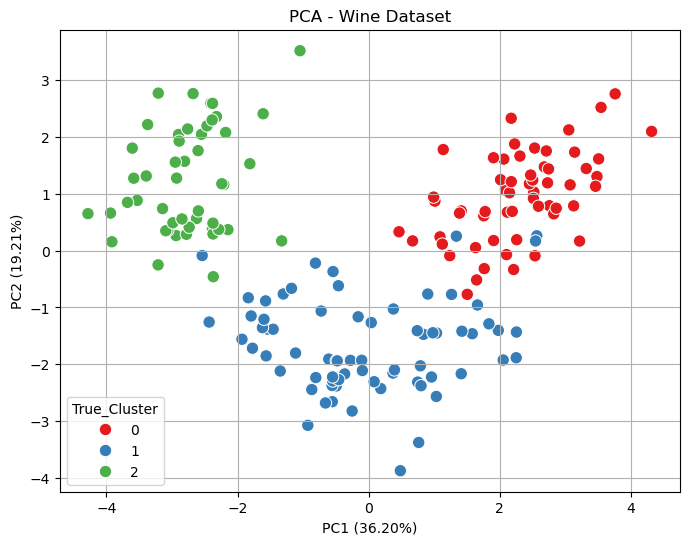

In [10]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Principal_Component_1",
    y="Principal_Component_2",
    hue="True_Cluster",
    data=df_pca,
    palette="Set1",
    s=80
)

plt.title("PCA - Wine Dataset")

plt.xlabel(f"PC1 ({explained_variance[0]*100:.2f}%)")
plt.ylabel(f"PC2 ({explained_variance[1]*100:.2f}%)")

plt.grid(True)
plt.show()

In [11]:
kmeans_pca = KMeans(
    n_clusters=3,
    init='k-means++',
    max_iter=300,
    n_init=10,
    random_state=42
)

clusters_pca = kmeans_pca.fit_predict(principal_components)

df_pca["KMeans_Cluster"] = clusters_pca

C:\Users\Lenovo\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


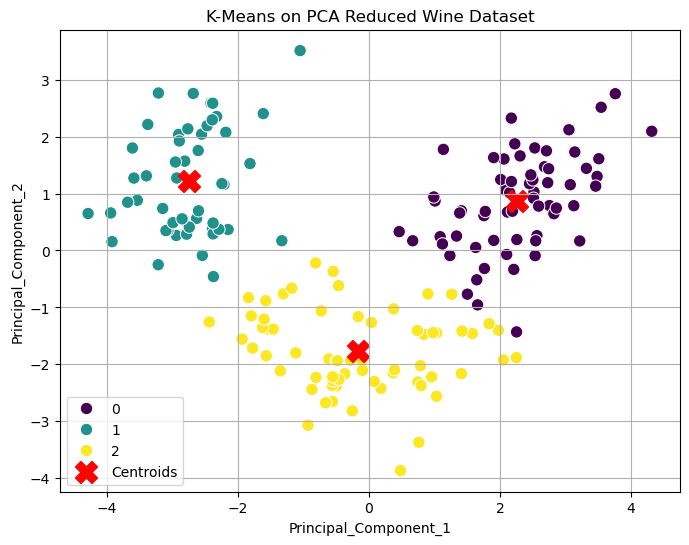

In [12]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Principal_Component_1",
    y="Principal_Component_2",
    hue="KMeans_Cluster",
    data=df_pca,
    palette="viridis",
    s=80
)

plt.scatter(
    kmeans_pca.cluster_centers_[:,0],
    kmeans_pca.cluster_centers_[:,1],
    color="red",
    marker="X",
    s=250,
    label="Centroids"
)

plt.title("K-Means on PCA Reduced Wine Dataset")

plt.legend()
plt.grid(True)
plt.show()

In [13]:
silhouette_avg_pca = silhouette_score(
    principal_components,
    clusters_pca
)

print("Silhouette Score (PCA):",
      round(silhouette_avg_pca,3))

Silhouette Score (PCA): 0.561
